## Data Cleaning

### Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Info/Features

In [5]:
dataset = pd.read_excel('../data/First Dataset.xlsx')

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     str    
 2   gender              61 non-null     str    
 3   age                 60 non-null     float64
 4   city                61 non-null     str    
 5   province            61 non-null     str    
 6   signup_date         61 non-null     str    
 7   membership_tier     61 non-null     str    
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     str    
 13  device              61 non-null     str    
 14  discount_used       61 non-null     str    
 15  returned_items      61 non-null     int64  
 16  satisfaction_score  6

In [7]:
dataset.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [8]:
dataset.isna().sum()

customer_id           0
first_name            0
gender                0
age                   1
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        1
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

### Handle Duplicate Records

In [9]:
dataset[dataset.duplicated()]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
60,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4


In [10]:
dataset.drop_duplicates(inplace=True)

### Check Columns Values and Outliers

In [11]:
dataset.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,60.000000,59.000000,60.000000,60.000000,59.000000,60.000000,60.000000,60.000000
mean,1030.500000,45.372881,17.383333,213.156500,3756.375424,198.600000,4.183333,2.983333
std,17.464249,19.284529,10.149880,130.509923,4298.515563,97.843043,2.683861,1.431979
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1015.750000,31.500000,10.750000,108.137500,1165.330000,134.250000,2.000000,2.000000
50%,1030.500000,45.000000,17.000000,165.435000,2140.380000,203.000000,4.000000,3.000000
75%,1045.250000,58.000000,24.500000,324.107500,4769.250000,273.750000,7.000000,4.000000
max,1060.000000,145.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.000000


The `Age` column has max value of 145, it was replaced with a NaN.

In [12]:
dataset.loc[(dataset['age']>90) | (dataset['age']<10), 'age'] = np.nan

Replaced missing values of `age` and `total_spending` columns with their median.

In [13]:
age_median = dataset['age'].median()
spending_median = dataset['total_spending'].median()
dataset['age'] = dataset['age'].fillna(age_median)
dataset['age'] = dataset['age'].astype(int)
dataset['total_spending'] = dataset['total_spending'].fillna(spending_median)

Checked the values of each categorical and discrete numerical columns

Values of `city` and `province` columns were logical and aligned.

In [14]:
dataset[['city', 'province']].value_counts()

city     province       
Tabriz   East Azerbaijan    12
Mashhad  Khorasan           11
Ahvaz    Khuzestan           8
Karaj    Alborz              7
Tehran   Tehran              6
Shiraz   Fars                6
Isfahan  Isfahan             5
Rasht    Gilan               5
Name: count, dtype: int64

In [15]:
dataset['membership_tier'].value_counts()

membership_tier
Gold      19
Bronze    18
VIP       15
Silver     8
Name: count, dtype: int64

In [16]:
dataset['payment_method'].value_counts()

payment_method
Online Wallet    23
Cash             19
Card             18
Name: count, dtype: int64

In [17]:
dataset['device'].value_counts()

device
Android    22
Web        20
iPhone     18
Name: count, dtype: int64

In [18]:
dataset['discount_used'].value_counts() # better to be encoded using 0 and 1

discount_used
No     34
Yes    26
Name: count, dtype: int64

In [19]:
dataset['satisfaction_score'].value_counts()

satisfaction_score
2    16
4    13
5    12
1    11
3     8
Name: count, dtype: int64

The `Gender` column contains incorrect values and should be corrected based on the customers' names. Since this dataset contains only 12 unique names, a dictionary can be used to map each name to the correct gender. For larger datasets, a name database or a gender inference library would be a more practical solution.

In [20]:
dataset['gender'].value_counts()

gender
F    35
M    25
Name: count, dtype: int64

In [21]:
dataset['first_name'].value_counts()

first_name
Sina      8
Neda      8
Reza      7
Kimia     7
Amir      6
Ali       6
Parsa     4
Arash     4
Maryam    4
Mina      3
Zahra     2
Sara      1
Name: count, dtype: int64

### Fix Illogical Values

In [22]:
name_based_gender = {
    'Sina': 'M',
    'Neda': 'F',
    'Reza': 'M',
    'Kimia': 'F',
    'Amir': 'M',
    'Ali': 'M',
    'Parsa': 'M',
    'Arash': 'M',
    'Maryam': 'F',
    'Mina': 'F',
    'Zahra': 'F',
    'Sara': 'F'
}

In [23]:
dataset['gender'] = dataset['first_name'].map(name_based_gender)

Checked if `purchase_count` is not less than `returned_items`

In [24]:
faulty_records = dataset['purchase_count'] < dataset['returned_items']
dataset[faulty_records]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
7,1008,Reza,M,23,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
14,1015,Kimia,F,47,Ahvaz,Khuzestan,2021-07-24,Gold,3,307.91,923.73,55,Card,Android,Yes,8,4
23,1024,Sina,M,53,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.00,298,Online Wallet,Android,No,2,1
28,1029,Ali,M,34,Tabriz,East Azerbaijan,2023-07-03,Gold,2,323.32,646.64,319,Cash,Web,Yes,4,5
36,1037,Zahra,F,42,Ahvaz,Khuzestan,2024-01-12,Gold,1,387.68,387.68,199,Cash,Web,Yes,7,2
55,1056,Kimia,F,61,Tabriz,East Azerbaijan,2025-01-25,Silver,1,449.81,449.81,240,Online Wallet,Web,No,4,2


Found the records with 0 `avg_order_value` and non-zero `total_spending` values to fix or drop

In [25]:
dataset[(dataset['total_spending'] == 0.00) & 
            (dataset['avg_order_value'] != 0.00)]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
23,1024,Sina,M,53,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.0,298,Online Wallet,Android,No,2,1


Since the record with the `customer_id` of '1024' had both logical issues we can drop that record.

In [26]:
dataset = dataset[dataset['customer_id'] != 1024]

Not having a reliable source to fix these issues yet, the records were replaced with NAN.

In [27]:
dataset.loc[faulty_records, ['purchase_count', 'returned_items']] = np.nan

### Datatype Changes

Checked the `signup_date` format and validation

In [28]:
dataset['signup_date'].dtype

<StringDtype(na_value=nan)>

Converted the `signup_date` to Datetime

In [29]:
dataset['signup_date'] = pd.to_datetime(
    dataset['signup_date'],
    format='%Y-%m-%d'
)

Mapped `discount_used` column values to 0 and 1.

In [30]:
dataset['discount_used'] = dataset['discount_used'].map(
    {'Yes': 1,
     'No': 0}
)

### Histograms

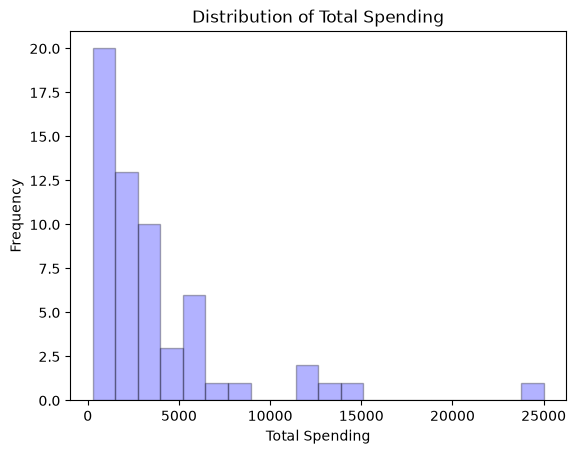

In [31]:
plt.hist(dataset['total_spending'],
         bins=20, color='blue', edgecolor='black',
         alpha=0.3)

plt.xlabel('Total Spending')
plt.ylabel('Frequency')
plt.title('Distribution of Total Spending')

plt.show()

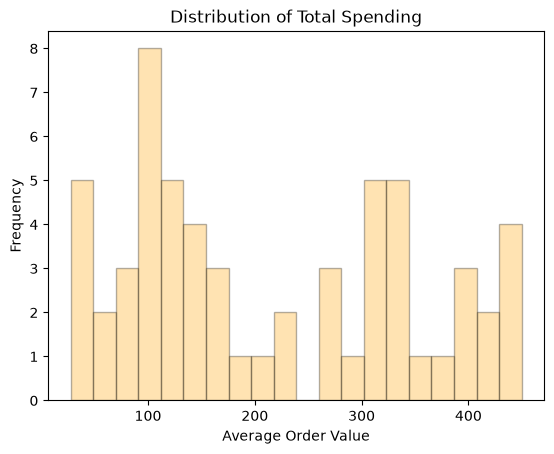

In [32]:
plt.hist(dataset['avg_order_value'], 
         bins=20, color='orange', edgecolor='black',
         alpha=0.3)

plt.xlabel('Average Order Value')
plt.ylabel('Frequency')
plt.title('Distribution of Total Spending')

plt.show()

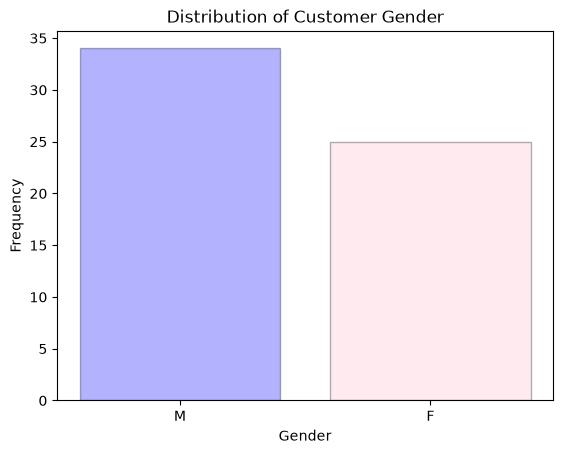

In [33]:
gender = dataset['gender'].value_counts()

gender_color = {'F': 'pink', 'M': 'blue'}

plt.bar(gender.index, gender.values,
         color=[gender_color[c] for c in gender.index],
         edgecolor='black', alpha=0.3)

plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Gender')

plt.show()

In [34]:
device_color = {
    'Android': 'green', 
    'Web': 'yellow', 
    'iPhone': 'blue'
}

pay_color = {
    'Card': 'royalblue',
    'Online Wallet': 'orange',
    'Cash': 'green'
}

member_color = {
    'Gold': 'gold',
    'Silver': 'silver',
    'Bronze': 'saddlebrown',
    'VIP': 'darkviolet'
}

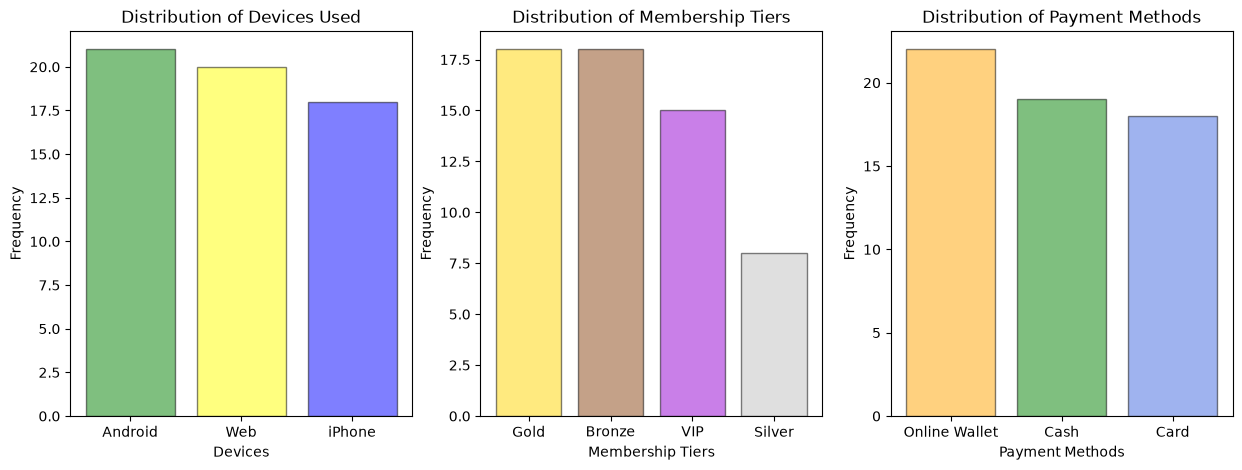

In [35]:
plt.figure(figsize=(15, 5))
# device barchart
device = dataset['device'].value_counts()

plt.subplot(1, 3, 1)
plt.bar(device.index, device.values,
         color=[device_color[c] for c in device.index],
         edgecolor='black',
         alpha=0.5)

plt.xlabel('Devices')
plt.ylabel('Frequency')
plt.title('Distribution of Devices Used')

# membership_tier barchart
membership = dataset['membership_tier'].value_counts()

plt.subplot(1, 3, 2)
plt.bar(membership.index, membership.values,
         color=[member_color[c] for c in membership.index],
         edgecolor='black',
         alpha=0.5)

plt.xlabel('Membership Tiers')
plt.ylabel('Frequency')
plt.title('Distribution of Membership Tiers')

# payment_method barchart
payment = dataset['payment_method'].value_counts()

plt.subplot(1, 3, 3)
plt.bar(payment.index, payment.values,
         color=[pay_color[c] for c in payment.index],
         edgecolor='black',
         alpha=0.5)

plt.xlabel('Payment Methods')
plt.ylabel('Frequency')
plt.title('Distribution of Payment Methods')

plt.show()

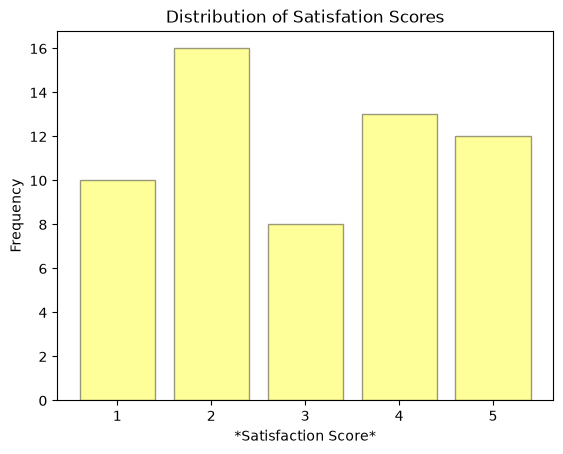

In [36]:
satisfaction = dataset['satisfaction_score'].value_counts()
plt.bar(satisfaction.index, satisfaction.values,
         color='yellow', edgecolor='black',
         alpha=0.4)

plt.xlabel('*Satisfaction Score*')
plt.ylabel('Frequency')
plt.title('Distribution of Satisfation Scores')

plt.show()

### Save

Stored the cleaned dataset in **cleaned_dataset.xlsx** file

In [41]:
dataset.to_excel('../data/cleaned_dataset_dinanadjari.xlsx', index=False)

In [42]:
cleaned = pd.read_excel('../data/cleaned_dataset_dinanadjari.xlsx')

In [43]:
cleaned.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17.0,121.53,2066.01,16,Card,Android,1,3.0,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12.0,326.47,3917.64,3,Card,Web,0,5.0,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21.0,59.46,1248.66,22,Online Wallet,iPhone,1,6.0,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23.0,266.15,6121.45,40,Card,Android,0,4.0,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23.0,169.54,3899.42,273,Online Wallet,Android,1,7.0,4
